In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
#Load dataset
df = pd.read_csv(r'C:\Users\Lion\Downloads\retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [10]:
#display the concise summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [12]:
#To generate discriptive statistics for numeric columns in a dataframe
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [15]:
#To view columns in the dataframe
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [19]:
#To detect missing values in the dataframe
df.isnull()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False


In [21]:
#To count the number of missing values
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [36]:
#dropping rows with missing values
df.dropna()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [39]:
#Replace NAN values in the numeric column (Age column) with the mean
mean_age =df['Age'].mean()
df['Age'] = df['Age'].fillna(mean_age)

In [206]:
df['Age'].isnull().sum()

np.int64(0)

In [208]:
#Replace all numerical values with the mean of their respective columns.
df['Age'] = df['Age'].fillna(df['Age'].mode()[0])

In [211]:
#To find the mean and median of Price per Unit
ppu_mean = df['Price per Unit'].mean()
ppu_median = df['Price per Unit'].median()
print(f"Mean: {ppu_mean}, Median: {ppu_median}")

Mean: 179.89, Median: 50.0


In [212]:
# To find missing 'Price Per Unit' column by median price of each group of unique Items in column
df['Price per Unit'] = df.groupby('Age')['Price per Unit'].transform(lambda x: x.fillna(x.median()))
#Using median to fill any missing value
df['Price per Unit'] = df['Price per Unit'].fillna(ppu_median)

In [213]:
#Quantity
qy_mean = df['Quantity'].mean()
qy_median = df['Quantity'].median()
print(f"Mean: {qy_mean}, Median: {qy_median}")

Mean: 2.514, Median: 3.0


In [215]:
#Fill 'Total Amount' as Price * Quantity
df['Total Amount'] = df['Total Amount'].fillna(df['Price per Unit'] * df['Quantity'])

In [216]:
# Confirm if missing values have been handled
print(df.isnull().sum())

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
year                0
Year                0
Month               0
Day                 0
dtype: int64


In [48]:
#To check for duplicates
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [50]:
df[df.duplicated()]

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount


In [53]:
#To remove all duplicated rows 
df = df.drop_duplicates()

In [55]:
#To reconfirm that there are no more duplicates
df[df.duplicated()]

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount


In [59]:
#checking data types
df = pd.DataFrame(df)
print(df.dtypes)

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [97]:
#To summarize key statistics
#Selecting numerical columns
numeric_cols = df.select_dtypes(include=['int64']).columns
print(numeric_cols)

Index(['Transaction ID', 'Age', 'Quantity', 'Price per Unit', 'Total Amount'], dtype='object')


In [67]:
#Selecting object columns(e.g strings)
object_cols = df.select_dtypes(include=['object']).columns
print(object_cols)

Index(['Date', 'Customer ID', 'Gender', 'Product Category'], dtype='object')


In [87]:
#To generate the descriptive statistics for non-numeric (object) columns in the Dataframe
df.select_dtypes(include='object').describe()

,Date,Customer ID,Gender,Product Category
count,1000,1000,1000,1000
unique,345,1000,2,3
top,2023-05-16,CUST1000,Female,Clothing
freq,11,1,510,351


In [88]:
#To generate the descriptive statistics for numeric columns in the Dataframe
df.select_dtypes(include='number').describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [89]:
#To count the number of unique values in each non-numeric (object) columns in the Dataframe
df.select_dtypes(include='object').nunique()

Date                 345
Customer ID         1000
Gender                 2
Product Category       3
dtype: int64

In [90]:
#To count the frequency of each unique value in each non-numeric(object) column of the Dataframe
df.select_dtypes(include='object').value_counts()

Date        Customer ID  Gender  Product Category
2024-01-01  CUST650      Male    Electronics         1
2023-01-01  CUST180      Male    Clothing            1
            CUST522      Male    Beauty              1
            CUST559      Female  Clothing            1
2023-01-02  CUST163      Female  Clothing            1
                                                    ..
2023-01-05  CUST391      Male    Beauty              1
            CUST367      Female  Electronics         1
2023-01-04  CUST683      Male    Beauty              1
            CUST231      Female  Clothing            1
            CUST032      Male    Beauty              1
Name: count, Length: 1000, dtype: int64

In [91]:
#To remove leading and trailing whitespace from strings in non-numeric(object) columns of a Dataframe
df.select_dtypes(include='object').apply(lambda x: x.str.strip())

,Date,Customer ID,Gender,Product Category
0,2023-11-24,CUST001,Male,Beauty
1,2023-02-27,CUST002,Female,Clothing
2,2023-01-13,CUST003,Male,Electronics
3,2023-05-21,CUST004,Male,Clothing
4,2023-05-06,CUST005,Male,Beauty
...,...,...,...,...
995,2023-05-16,CUST996,Male,Clothing
996,2023-11-17,CUST997,Male,Beauty
997,2023-10-29,CUST998,Female,Beauty
998,2023-12-05,CUST999,Female,Electronics


In [95]:
#To convert strings to lowercase in non-numeric(object) columns in a Dataframe
df.select_dtypes(include='object').apply(lambda x: x.str.lower())

,Date,Customer ID,Gender,Product Category
0,2023-11-24,cust001,male,beauty
1,2023-02-27,cust002,female,clothing
2,2023-01-13,cust003,male,electronics
3,2023-05-21,cust004,male,clothing
4,2023-05-06,cust005,male,beauty
...,...,...,...,...
995,2023-05-16,cust996,male,clothing
996,2023-11-17,cust997,male,beauty
997,2023-10-29,cust998,female,beauty
998,2023-12-05,cust999,female,electronics


In [102]:
#To replace spaces with underscores in strings within non-numeric(object) columns in the Dataframe
df.select_dtypes(include='object').apply(lambda x: x.str.replace(' ', '_'))

,Date,Customer ID,Gender,Product Category
0,2023-11-24,CUST001,Male,Beauty
1,2023-02-27,CUST002,Female,Clothing
2,2023-01-13,CUST003,Male,Electronics
3,2023-05-21,CUST004,Male,Clothing
4,2023-05-06,CUST005,Male,Beauty
...,...,...,...,...
995,2023-05-16,CUST996,Male,Clothing
996,2023-11-17,CUST997,Male,Beauty
997,2023-10-29,CUST998,Female,Beauty
998,2023-12-05,CUST999,Female,Electronics


In [105]:
df.groupby('Quantity')['Age'].mean()

Quantity
1    41.557312
2    42.436214
3    40.290456
4    41.277567
Name: Age, dtype: float64

In [114]:
#To group the Dataframe by 'Quantity' column and calculate the multiple aggregation statistics ('mean','median','std') for the 'Age' column.
df.groupby('Quantity')['Age'].agg(['mean', 'median', 'std'])

,mean,median,std
Quantity,,,
1,41.557312,42.0,14.060868
2,42.436214,43.0,13.868592
3,40.290456,40.0,13.292490
4,41.277567,42.0,13.486314


In [116]:
#To group the Dataframe by 'Quantity' column and calculate the multiple aggregation statistics ('mean','median','std') for the 'Age' column and converting the result to a flat Dataframe.
df.groupby('Quantity')['Age'].agg(['mean', 'median', 'std']).reset_index()

,Quantity,mean,median,std
0,1,41.557312,42.0,14.060868
1,2,42.436214,43.0,13.868592
2,3,40.290456,40.0,13.292490
3,4,41.277567,42.0,13.486314


In [134]:
#Extract and create a new column for year,month and day. 
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,year,Year,Month,Day
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,2023,November,24
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2023,February,27
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,2023,January,13
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,2023,May,21
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,2023,May,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,2023,2023,May,16
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,2023,2023,November,17
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,2023,2023,October,29
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,2023,2023,December,5


In [136]:
df[df['Month'] == 'June'].groupby('Product Category')['Quantity'].sum()

Product Category
Beauty         66
Clothing       67
Electronics    64
Name: Quantity, dtype: int64

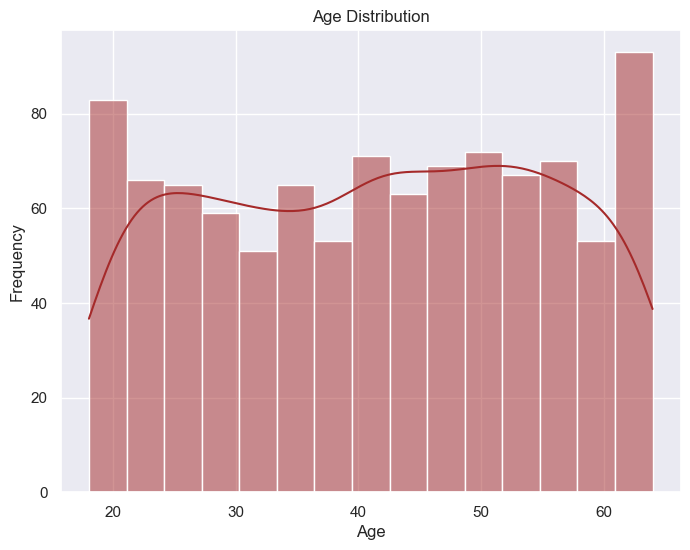

In [224]:
#To create visualizations to illustrate insights
#Histogram
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Age', bins=15,kde=True, color='brown')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#what does the distribution look like?
# The distribution appears to have majority of 40 to 50 years old customers and few are within 20years and 60 and above.

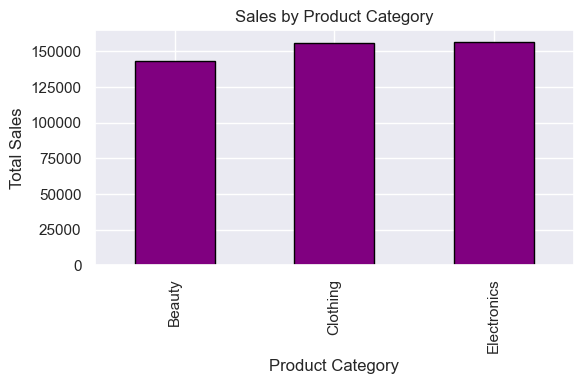

In [205]:
#create a bar chart comparing Product Category by Total Amount to get the Sales by Product Cateory
plt.figure(figsize=(6, 4))
category_sales = df.groupby('Product Category')['Total Amount'].sum()
category_sales.plot(kind='bar', color='purple', edgecolor='black')
plt.title("Sales by Product Category")
plt.xlabel("Product Category")  
plt.ylabel("Total Sales")     
plt.grid(True)
plt.tight_layout()
plt.show()

In [225]:
#what does the visualization reveal?
# The visualization reveals that certain categories, such as 'Electronics' and 'Clothing', have significantly higher average prices compared to the other 'Beauty'.

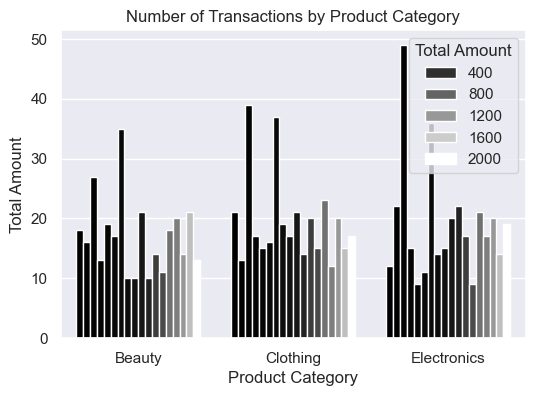

In [203]:
#Create a count plot using Product Category by Total Amount
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Product Category',hue='Total Amount', palette='grey')
plt.title('Number of Transactions by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.show()

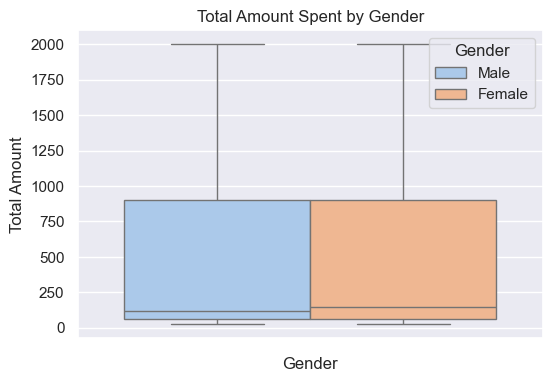

In [193]:
#Create a boxplot comparing Total Amount spent by Gender.
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, hue='Gender', y='Total Amount', palette='pastel')
plt.title('Total Amount Spent by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Amount')
plt.show()

In [229]:
#Both the male and female gender have equal number of total amount.

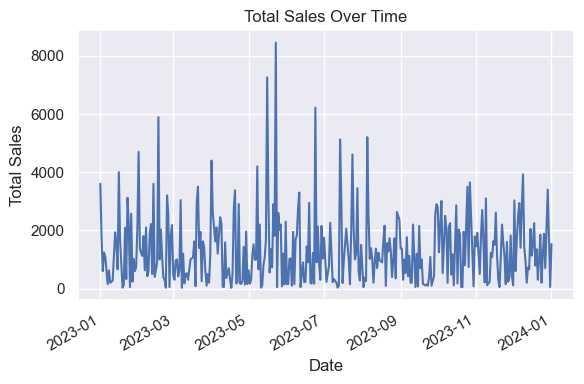

In [202]:
# Group by date and sum
sales_by_date = df.groupby('Date')['Total Amount'].sum()
plt.figure(figsize=(6, 4))
sales_by_date.plot()
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

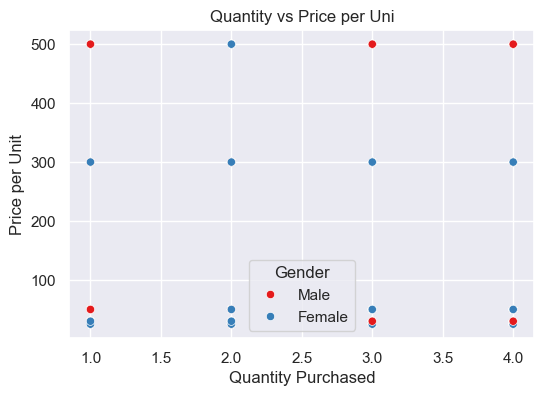

In [218]:
#Create a scattered plot using Quantity by Price per Unit
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Quantity', y='Price per Unit', hue='Gender', palette='Set1')
plt.title('Quantity vs Price per Uni')
plt.xlabel('Quantity Purchased')
plt.ylabel('Price per Unit')
plt.legend(title='Gender')
plt.grid(True)
plt.show()

In [228]:
#what trends was observed in the sales pattern?
# The sales pattern shows a certin gender (Female) buys more products than the other gender(male).

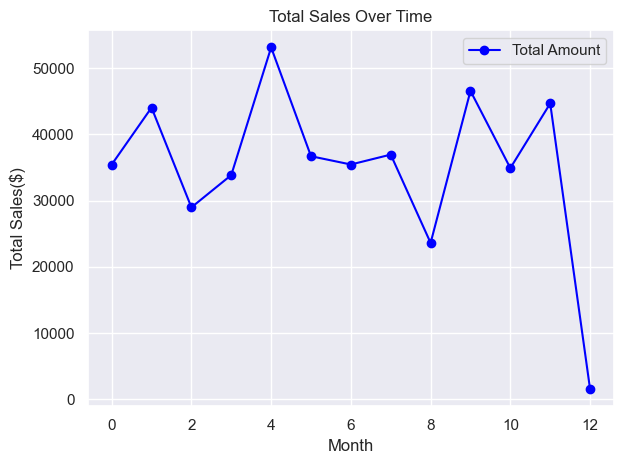

In [226]:
#create a line chart showing total sales over time(by month)
df['Date'] = pd.to_datetime(df['Date'])
df['YearMonth'] = df['Date'].dt.to_period('M')
#group data by YearMonth and sum the sales
monthly_sales = df.groupby(df['YearMonth'])['Total Amount'].sum().reset_index()
#convert YearMonth to string format using.astype(str)
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)
monthly_sales.plot(kind='line', marker='o', color='blue')
plt.title('Total Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales($)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [227]:
#what trends was observed in the sales pattern?
# The sales pattern shows a general downward trend over time, with some fluctuations. There are noticeable fall during certain months, indicating seasonal trends.